# IT3051 Fundamentals of Data Mining
## E-commerce Customer Soft Segmentation
### Phase 2–4: Feature Audit, EDA, Leakage/Redundancy Analysis & Preprocessing

**Project objective:** Discover customer groups using unsupervised clustering, with emphasis on soft clustering.  
**Important design rule:** `customer_lifetime_value_usd` and `churn_risk_score` are kept out of clustering and used later for business prioritization.

This notebook deliberately performs **EDA before final feature selection/preprocessing** so that preprocessing decisions are evidence-based.

## 1. Imports and display settings

In [1]:
import warnings
warnings.filterwarnings("ignore")

from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.preprocessing import StandardScaler, OneHotEncoder, OrdinalEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.feature_selection import VarianceThreshold

pd.set_option("display.max_columns", 100)
pd.set_option("display.max_rows", 200)
pd.set_option("display.float_format", lambda x: f"{x:,.4f}")

## 2. Load the original dataset

Change `DATA_PATH` if your CSV is stored elsewhere.

In [2]:
# Locate project root reliably whether the notebook is executed from repo root or notebooks/
current_dir = Path.cwd().resolve()
if (current_dir / "data" / "raw" / "E-commerce_Customer_Segmentation_2026.csv").exists():
    PROJECT_ROOT = current_dir
elif (current_dir.parent / "data" / "raw" / "E-commerce_Customer_Segmentation_2026.csv").exists():
    PROJECT_ROOT = current_dir.parent
else:
    PROJECT_ROOT = current_dir

RAW_DATA_DIR = PROJECT_ROOT / "data" / "raw"
PROCESSED_DATA_DIR = PROJECT_ROOT / "data" / "processed"
MODELS_DIR = PROJECT_ROOT / "models"
RESULTS_DIR = PROJECT_ROOT / "results"
FIGURES_DIR = RESULTS_DIR / "figures"

# Create directories automatically if they do not exist
for directory in [RAW_DATA_DIR, PROCESSED_DATA_DIR, MODELS_DIR, RESULTS_DIR, FIGURES_DIR]:
    directory.mkdir(parents=True, exist_ok=True)

DATA_PATH = RAW_DATA_DIR / "E-commerce_Customer_Segmentation_2026.csv"
df = pd.read_csv(DATA_PATH)

print("Project root:", PROJECT_ROOT)
print("Dataset path:", DATA_PATH)
print("Shape:", df.shape)
display(df.head())


Project root: C:\Users\ASUS\Pictures\final fdm
Dataset path: C:\Users\ASUS\Pictures\final fdm\data\raw\E-commerce_Customer_Segmentation_2026.csv
Shape: (50000, 53)


,customer_id,customer_segment,segment_category,age,age_group,gender,country,city,income_bracket,education_level,employment_type,marital_status,tenure_months,total_purchases,avg_order_value_usd,total_spent_usd,purchase_frequency,days_since_last_purchase,preferred_category_1,preferred_category_2,preferred_category_3,shopping_channel,device_used,payment_method,return_count,complaint_count,satisfaction_score,satisfaction_level,loyalty_tier,email_open_rate,click_through_rate,conversion_rate,social_media_presence,customer_lifetime_value_usd,customer_acquisition_cost_usd,customer_profitability_usd,recency_score,frequency_score,monetary_score,rfm_score,churn_risk_score,customer_health_score,dataset_year,customer_value_category,activity_status,health_status,churn_risk_category,rfm_category,profitability_category,engagement_level,behavior_segment,device_preference,clv_category
0,CUST-000001,Consumer,High Value Inactive,70,65+,Male,Canada,Winnipeg,150K+,Professional,Unemployed,Widowed,77,28,912.6000,"25,552.8000",Quarterly,63,Sports & Fitness,Home & Kitchen,NaN,In-Store,Tablet,Debit Card,15,13,5,Very Satisfied,Platinum,0.0180,0.0670,0.0220,NaN,"21,281.0700",96.7400,"21,184.3300",3,3,4,10,39,100,2026,High,Dormant,Excellent,Low,Potential Loyalists,High Profit,Low,Regular Buyer,Multi-Device,High CLV
1,CUST-000002,Premium,High Value Inactive,53,45-54,Female,Germany,Essen,25K-50K,High School,Student,Divorced,80,75,300.8600,"22,564.5000",Rarely,342,Automotive,Beauty,Fashion,Marketplace,Desktop,Bank Transfer,1,14,5,Very Satisfied,Gold,0.0840,0.0850,0.2930,NaN,"28,347.2100",199.2800,"28,147.9300",1,4,3,8,42,100,2026,Medium,Inactive,Excellent,Medium,At Risk,High Profit,Low,Occasional Buyer,Desktop-First,High CLV
2,CUST-000003,Consumer,High Value Inactive,82,65+,Male,Mexico,Puebla,75K-100K,Bachelors,Student,Married,86,163,663.9100,"108,217.3300",Quarterly,64,Fashion,Automotive,Beauty,In-Store,Tablet,Bank Transfer,1,4,3,Neutral,Diamond,0.2790,0.4280,0.2220,NaN,"103,909.8400",112.3900,"103,797.4500",3,5,5,13,0,100,2026,Very High,Dormant,Excellent,Very Low,Champions,High Profit,Low,Regular Buyer,Multi-Device,High CLV
3,CUST-000004,Enterprise,High Value Active,18,18-24,Male,Singapore,Singapore,150K+,Masters,Retired,Divorced,26,192,613.6000,"117,811.2000",Weekly,2,Electronics,Toys,NaN,Online,Mobile,Credit Card,11,8,5,Very Satisfied,Diamond,0.8990,0.2820,0.1420,"Twitter, YouTube, TikTok","171,318.4100",140.7100,"171,177.7000",5,5,5,15,14,100,2026,Very High,Active,Excellent,Very Low,Champions,High Profit,High,Frequent Buyer,Mobile-First,High CLV
4,CUST-000005,Premium,High Value Active,64,55-64,Male,United Arab Emirates,Fujairah,150K+,PhD,Retired,Divorced,90,31,651.6500,"20,201.1500",Weekly,4,Home & Kitchen,Office Supplies,Grocery,Online,Desktop,Credit Card,7,11,1,Very Dissatisfied,Gold,0.8350,0.0940,0.1800,"TikTok, YouTube","24,465.4700",52.8200,"24,412.6500",5,3,3,11,45,60,2026,Medium,Active,Fair,Medium,Loyal,High Profit,Medium,Occasional Buyer,Desktop-First,High CLV


## 3. Basic dataset structure

In [3]:
print(f"Rows: {df.shape[0]:,}")
print(f"Columns: {df.shape[1]}")
print("\nColumn names:")
for i, col in enumerate(df.columns, 1):
    print(f"{i:02d}. {col}")

Rows: 50,000
Columns: 53

Column names:
01. customer_id
02. customer_segment
03. segment_category
04. age
05. age_group
06. gender
07. country
08. city
09. income_bracket
10. education_level
11. employment_type
12. marital_status
13. tenure_months
14. total_purchases
15. avg_order_value_usd
16. total_spent_usd
17. purchase_frequency
18. days_since_last_purchase
19. preferred_category_1
20. preferred_category_2
21. preferred_category_3
22. shopping_channel
23. device_used
24. payment_method
25. return_count
26. complaint_count
27. satisfaction_score
28. satisfaction_level
29. loyalty_tier
30. email_open_rate
31. click_through_rate
32. conversion_rate
33. social_media_presence
34. customer_lifetime_value_usd
35. customer_acquisition_cost_usd
36. customer_profitability_usd
37. recency_score
38. frequency_score
39. monetary_score
40. rfm_score
41. churn_risk_score
42. customer_health_score
43. dataset_year
44. customer_value_category
45. activity_status
46. health_status
47. churn_risk_cat

In [4]:
# Data types and non-null counts
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 53 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   customer_id                    50000 non-null  str    
 1   customer_segment               50000 non-null  str    
 2   segment_category               50000 non-null  str    
 3   age                            50000 non-null  int64  
 4   age_group                      50000 non-null  str    
 5   gender                         50000 non-null  str    
 6   country                        50000 non-null  str    
 7   city                           50000 non-null  str    
 8   income_bracket                 50000 non-null  str    
 9   education_level                50000 non-null  str    
 10  employment_type                50000 non-null  str    
 11  marital_status                 50000 non-null  str    
 12  tenure_months                  50000 non-null  int64  
 1

In [5]:
# Compact feature audit table
audit = pd.DataFrame({
    "dtype": df.dtypes.astype(str),
    "non_null": df.notna().sum(),
    "missing": df.isna().sum(),
    "missing_pct": (df.isna().mean() * 100).round(2),
    "unique": df.nunique(dropna=False)
}).sort_values(["missing_pct", "unique"], ascending=[False, True])

display(audit)

,dtype,non_null,missing,missing_pct,unique
preferred_category_3,str,16743,33257,66.5100,13
preferred_category_2,str,33257,16743,33.4900,13
social_media_presence,str,37580,12420,24.8400,157
loyalty_tier,str,48728,1272,2.5400,6
dataset_year,int64,50000,0,0.0000,1
gender,str,50000,0,0.0000,2
engagement_level,str,50000,0,0.0000,3
device_preference,str,50000,0,0.0000,3
clv_category,str,50000,0,0.0000,3
customer_segment,str,50000,0,0.0000,4


## 4. Duplicate checks

We check both complete-row duplicates and duplicated customer IDs.

In [6]:
print("Exact duplicate rows:", df.duplicated().sum())
print("Duplicated customer_id values:", df["customer_id"].duplicated().sum())
print("Unique customer IDs:", df["customer_id"].nunique())

Exact duplicate rows: 0
Duplicated customer_id values: 0
Unique customer IDs: 50000


## 5. Missing-value analysis

In [7]:
missing = pd.DataFrame({
    "missing_count": df.isna().sum(),
    "missing_pct": df.isna().mean() * 100
})
missing = missing[missing["missing_count"] > 0].sort_values("missing_pct", ascending=False)

display(missing)

,missing_count,missing_pct
preferred_category_3,33257,66.5140
preferred_category_2,16743,33.4860
social_media_presence,12420,24.8400
loyalty_tier,1272,2.5440


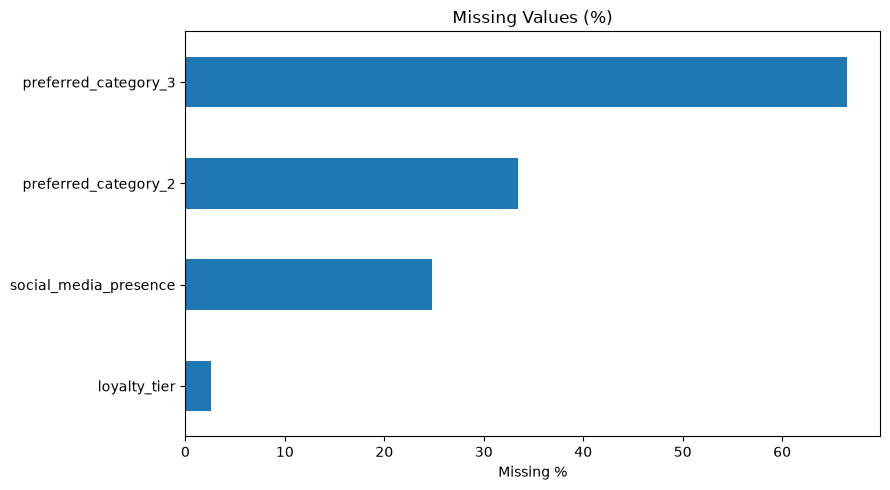

In [8]:
if not missing.empty:
    ax = missing["missing_pct"].sort_values().plot(
        kind="barh", figsize=(9, 5), title="Missing Values (%)"
    )
    ax.set_xlabel("Missing %")
    plt.tight_layout()
    plt.show()

### Missingness interpretation

Do **not** automatically impute every missing value.

For example, missing values in `preferred_category_2` or `preferred_category_3` may mean that a customer simply has fewer recorded preferences. We first inspect the patterns.

In [9]:
preference_cols = ["preferred_category_1", "preferred_category_2", "preferred_category_3"]

for col in preference_cols:
    print(f"\n{col}")
    display(df[col].value_counts(dropna=False).head(15))


preferred_category_1


preferred_category_1
Grocery                   4282
Automotive                4218
Sports & Fitness          4209
Fashion                   4205
Home & Kitchen            4205
Books                     4165
Electronics               4152
Office Supplies           4129
Health & Personal Care    4127
Pet Supplies              4113
Toys                      4112
Beauty                    4083
Name: count, dtype: int64


preferred_category_2


preferred_category_2
NaN                       16743
Office Supplies            2880
Grocery                    2879
Fashion                    2794
Books                      2771
Beauty                     2767
Sports & Fitness           2763
Home & Kitchen             2761
Pet Supplies               2758
Toys                       2737
Health & Personal Care     2726
Electronics                2720
Automotive                 2701
Name: count, dtype: int64


preferred_category_3


preferred_category_3
NaN                       33257
Automotive                 1427
Home & Kitchen             1427
Sports & Fitness           1410
Pet Supplies               1404
Grocery                    1403
Electronics                1401
Office Supplies            1397
Toys                       1393
Books                      1386
Health & Personal Care     1381
Beauty                     1369
Fashion                    1345
Name: count, dtype: int64

In [10]:
if "social_media_presence" in df.columns:
    display(df["social_media_presence"].value_counts(dropna=False).head(25))

if "loyalty_tier" in df.columns:
    display(df["loyalty_tier"].value_counts(dropna=False))

social_media_presence
NaN                    12420
Twitter                 2217
Facebook                2181
YouTube                 2079
LinkedIn                2052
TikTok                  2048
Instagram               2023
Twitter, TikTok          450
Instagram, LinkedIn      439
TikTok, LinkedIn         437
YouTube, Instagram       435
Instagram, TikTok        434
TikTok, Facebook         433
LinkedIn, Twitter        432
Twitter, Facebook        429
YouTube, Twitter         425
Twitter, Instagram       424
LinkedIn, Facebook       422
Instagram, YouTube       422
Facebook, YouTube        422
Facebook, LinkedIn       420
Instagram, Facebook      418
LinkedIn, TikTok         414
Twitter, YouTube         413
TikTok, Twitter          412
Name: count, dtype: int64

loyalty_tier
Diamond     20300
Platinum    10535
Gold         9446
Bronze       4259
Silver       4188
NaN          1272
Name: count, dtype: int64

## 6. Constant and near-constant features

A constant feature cannot help separate customers into clusters.

In [11]:
nunique = df.nunique(dropna=False)
constant_cols = nunique[nunique <= 1].index.tolist()

print("Constant columns:", constant_cols)

Constant columns: ['dataset_year']


In [12]:
near_constant = []

for col in df.columns:
    freq = df[col].value_counts(dropna=False, normalize=True)
    if len(freq) > 0 and freq.iloc[0] >= 0.95:
        near_constant.append((col, freq.iloc[0]))

pd.DataFrame(near_constant, columns=["feature", "largest_category_share"]).sort_values(
    "largest_category_share", ascending=False
)

,feature,largest_category_share
0,dataset_year,1.0000
1,profitability_category,0.9754


## 7. Numerical validity checks

This checks for negative values, infinities, ranges, and summary statistics.  
A negative value is not automatically wrong; interpretation depends on the feature.

In [13]:
numeric_cols = df.select_dtypes(include=np.number).columns.tolist()

negative_counts = (df[numeric_cols] < 0).sum()
negative_counts = negative_counts[negative_counts > 0].sort_values(ascending=False)

print("Numeric columns containing negative values:")
display(negative_counts.to_frame("negative_count"))

Numeric columns containing negative values:


,negative_count
customer_profitability_usd,298


In [14]:
print("Infinite values:")
inf_counts = pd.Series({
    c: np.isinf(df[c].to_numpy(dtype=float, na_value=np.nan)).sum()
    for c in numeric_cols
})
display(inf_counts[inf_counts > 0].to_frame("infinite_count"))

Infinite values:


,infinite_count


In [15]:
numeric_summary = df[numeric_cols].describe().T
numeric_summary["median"] = df[numeric_cols].median()
numeric_summary["skewness"] = df[numeric_cols].skew()
display(numeric_summary)

,count,mean,std,min,25%,50%,75%,max,median,skewness
age,"50,000.0000",45.6480,18.3680,18.0000,30.0000,45.0000,60.0000,84.0000,45.0000,0.2718
tenure_months,"50,000.0000",59.7482,34.3101,1.0000,30.0000,60.0000,90.0000,119.0000,60.0000,0.0055
total_purchases,"50,000.0000",99.4185,57.7802,0.0000,49.0000,99.0000,150.0000,199.0000,99.0000,0.0022
avg_order_value_usd,"50,000.0000",505.3669,285.6040,10.0500,259.0675,504.7900,752.7025,999.9900,504.7900,0.0010
total_spent_usd,"50,000.0000","50,266.5462","44,071.2092",0.0000,"13,893.5775","37,541.6250","76,811.2425","198,574.1400","37,541.6250",0.9741
days_since_last_purchase,"50,000.0000",62.9712,93.2814,0.0000,2.0000,19.0000,77.0000,365.0000,19.0000,1.7598
return_count,"50,000.0000",9.5117,5.7826,0.0000,4.0000,10.0000,15.0000,19.0000,10.0000,-0.0009
complaint_count,"50,000.0000",6.9938,4.3242,0.0000,3.0000,7.0000,11.0000,14.0000,7.0000,0.0013
satisfaction_score,"50,000.0000",3.0080,1.4180,1.0000,2.0000,3.0000,4.0000,5.0000,3.0000,-0.0078
email_open_rate,"50,000.0000",0.5003,0.2895,0.0000,0.2510,0.5000,0.7520,1.0000,0.5000,-0.0041


## 8. Domain/range sanity checks

In [16]:
range_rules = {
    "age": (0, 120),
    "tenure_months": (0, None),
    "total_purchases": (0, None),
    "avg_order_value_usd": (0, None),
    "total_spent_usd": (0, None),
    "days_since_last_purchase": (0, None),
    "return_count": (0, None),
    "complaint_count": (0, None),
    "satisfaction_score": (1, 5),
    "email_open_rate": (0, 1),
    "click_through_rate": (0, 1),
    "conversion_rate": (0, 1),
    "customer_lifetime_value_usd": (0, None),
    "customer_acquisition_cost_usd": (0, None),
    "recency_score": (1, 5),
    "frequency_score": (1, 5),
    "monetary_score": (1, 5),
    "rfm_score": (3, 15),
    "churn_risk_score": (0, 100),
    "customer_health_score": (0, 100),
}

range_check_rows = []
for col, (low, high) in range_rules.items():
    if col not in df.columns:
        continue
    invalid = pd.Series(False, index=df.index)
    if low is not None:
        invalid |= df[col] < low
    if high is not None:
        invalid |= df[col] > high
    range_check_rows.append({
        "feature": col,
        "min": df[col].min(),
        "max": df[col].max(),
        "invalid_count": int(invalid.sum())
    })

display(pd.DataFrame(range_check_rows))

,feature,min,max,invalid_count
0,age,18.0000,84.0000,0
1,tenure_months,1.0000,119.0000,0
2,total_purchases,0.0000,199.0000,0
3,avg_order_value_usd,10.0500,999.9900,0
4,total_spent_usd,0.0000,"198,574.1400",0
5,days_since_last_purchase,0.0000,365.0000,0
6,return_count,0.0000,19.0000,0
7,complaint_count,0.0000,14.0000,0
8,satisfaction_score,1.0000,5.0000,0
9,email_open_rate,0.0000,1.0000,0


## 9. Numerical distributions and skewness

In [17]:
skewness = df[numeric_cols].skew().sort_values(
    key=lambda x: x.abs(), ascending=False
)
display(skewness.to_frame("skewness"))

,skewness
days_since_last_purchase,1.7598
customer_lifetime_value_usd,1.1597
customer_profitability_usd,1.1597
frequency_score,-1.0825
recency_score,-1.0534
customer_health_score,-0.9923
total_spent_usd,0.9741
monetary_score,-0.7393
rfm_score,-0.6993
churn_risk_score,0.5008


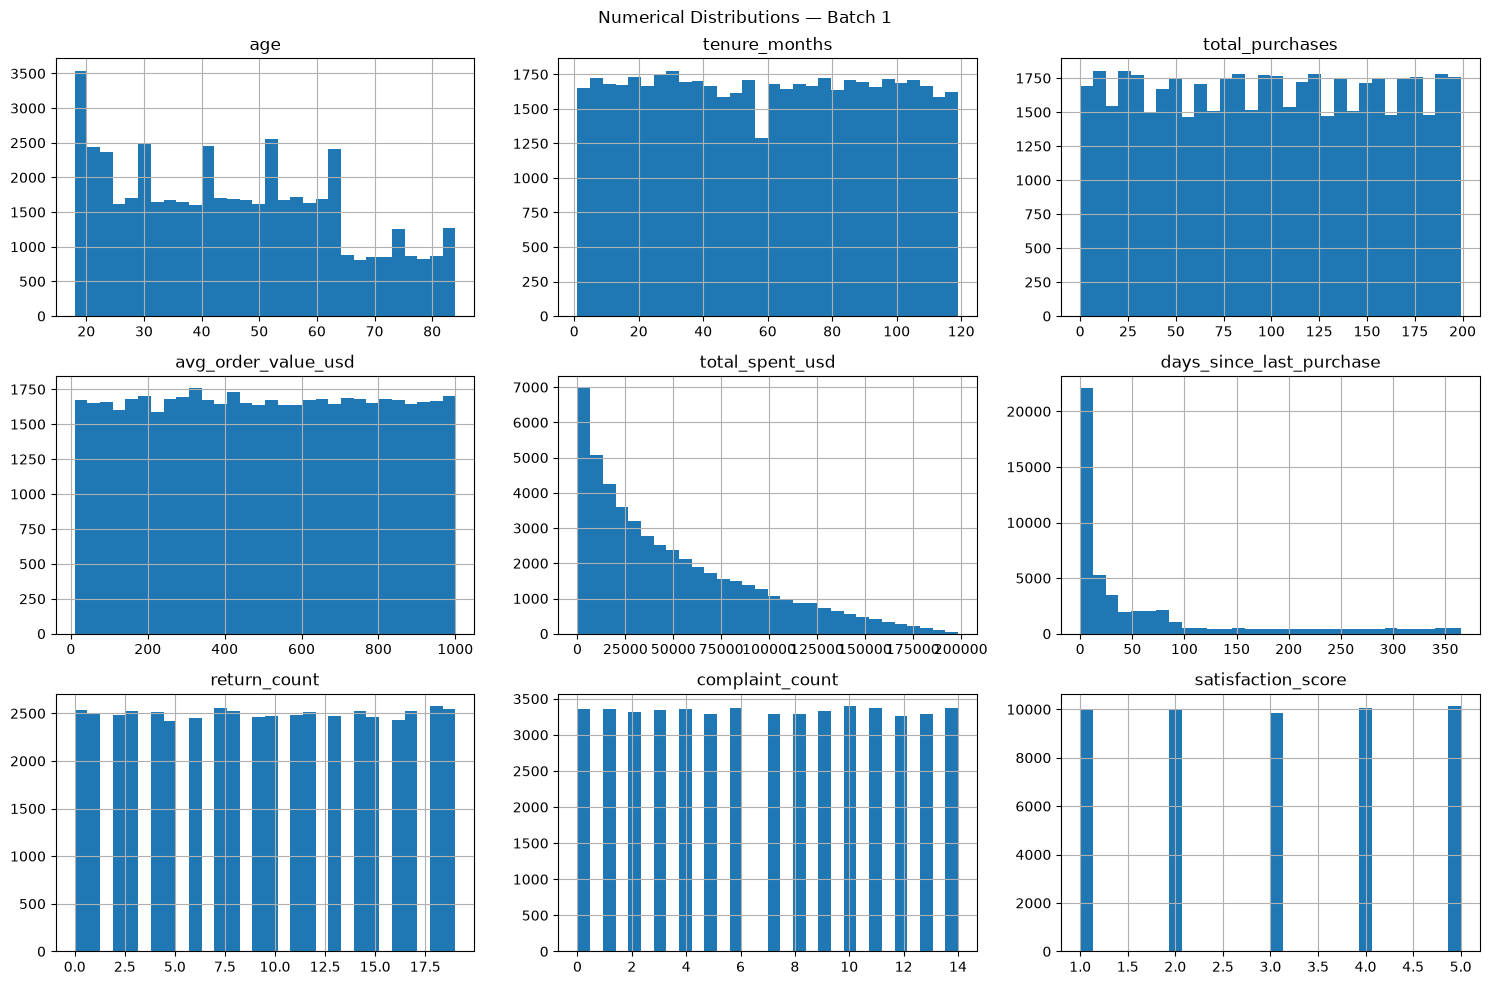

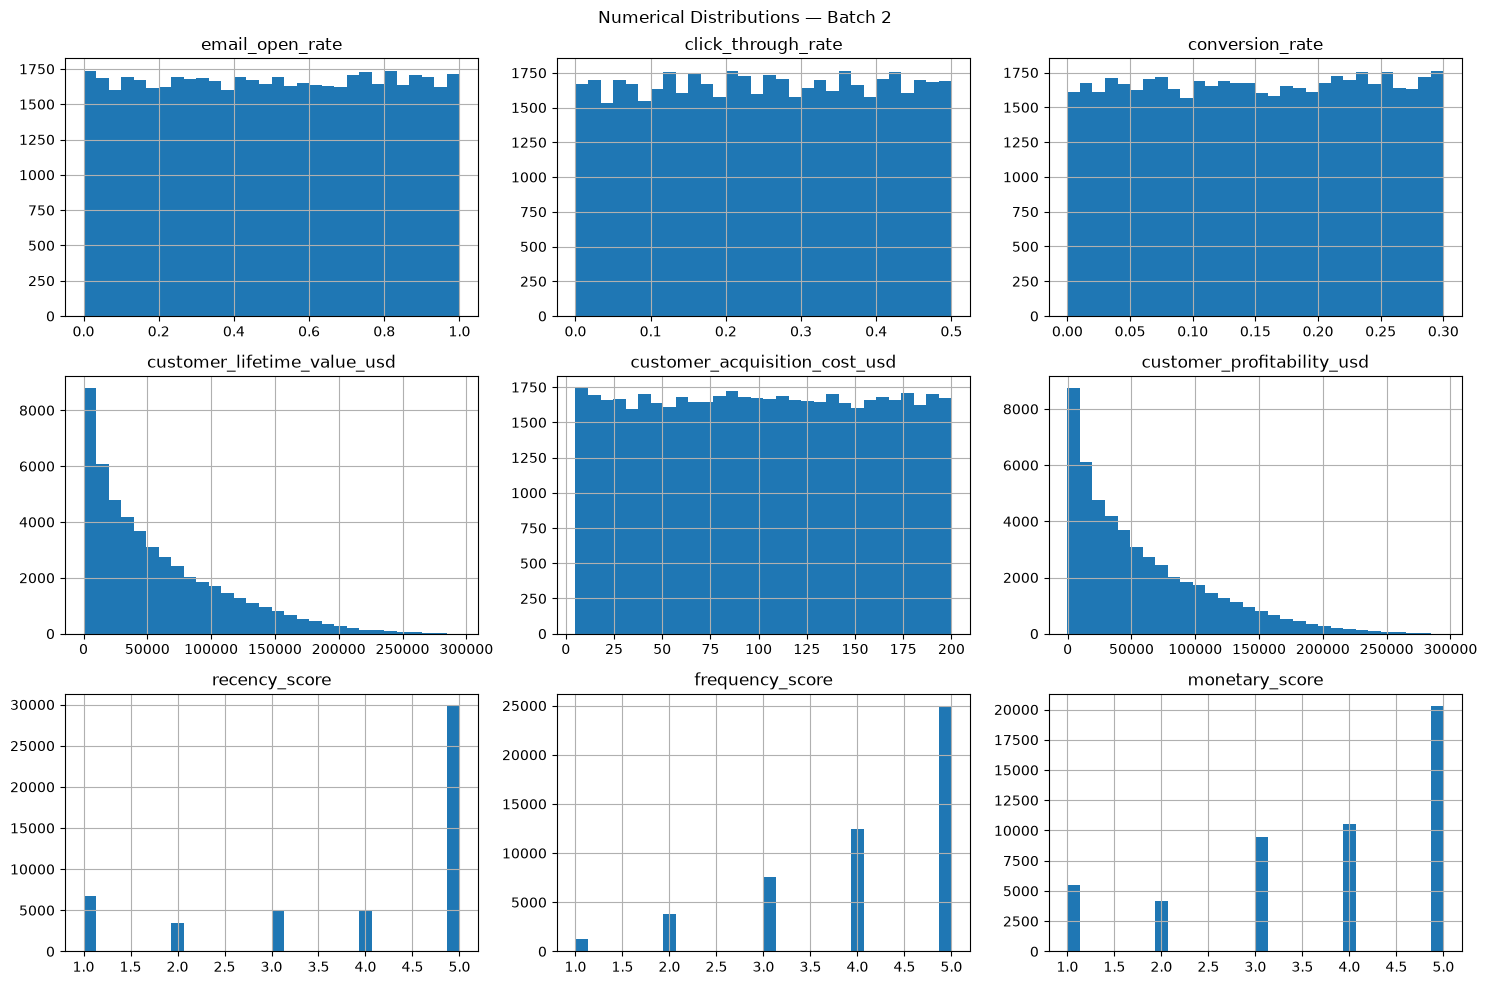

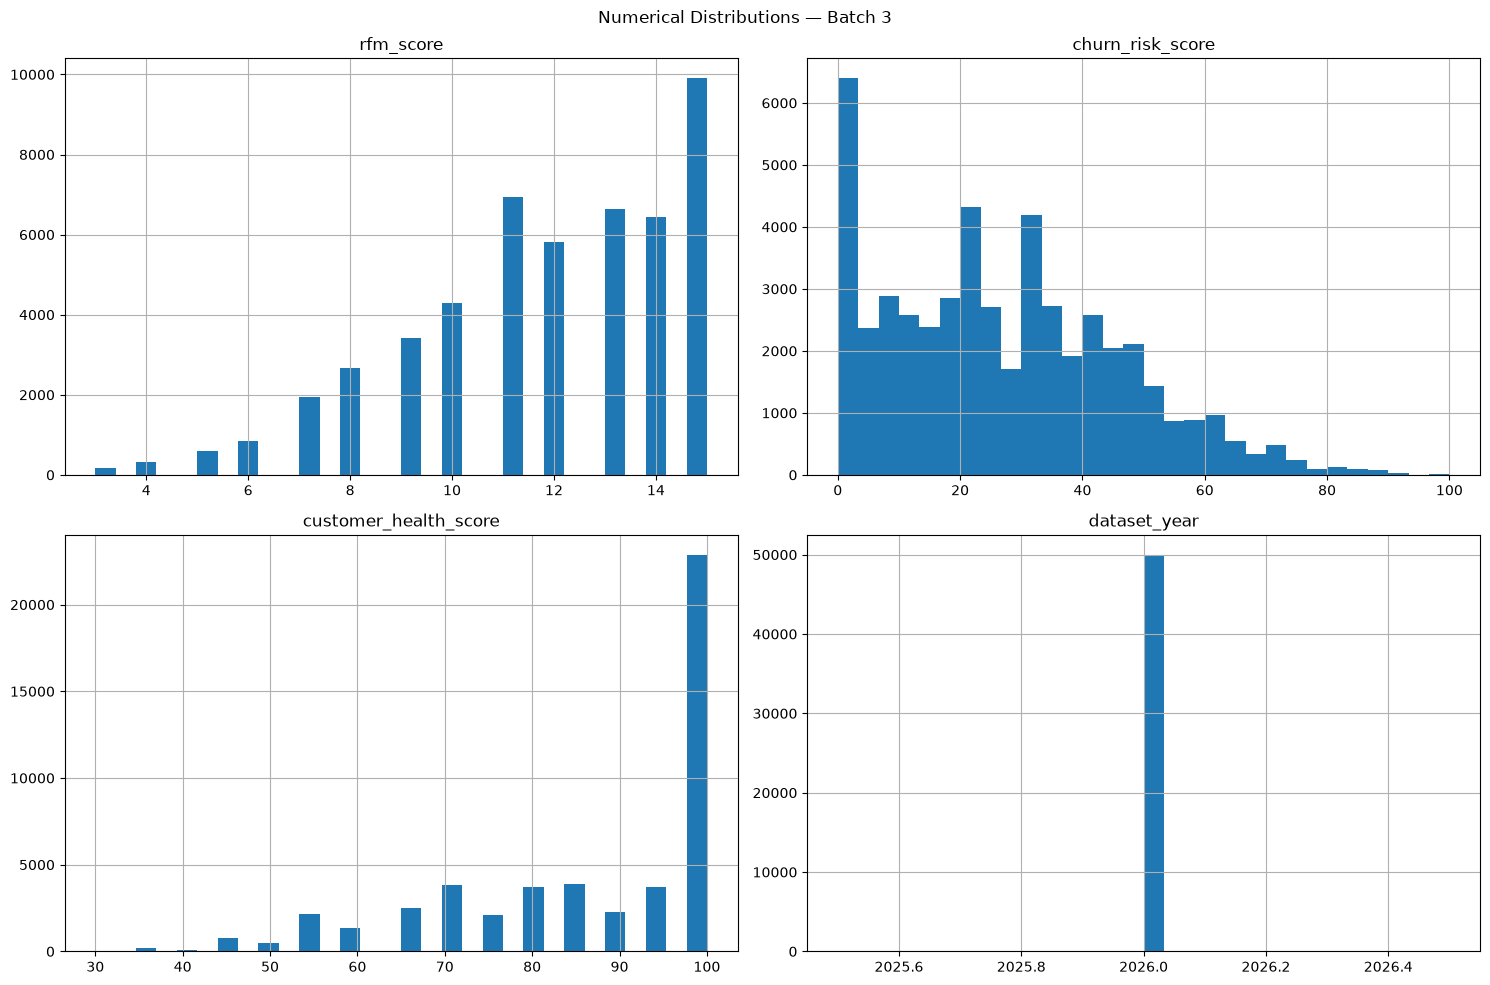

In [18]:
# Histograms in manageable batches
for start in range(0, len(numeric_cols), 9):
    cols = numeric_cols[start:start+9]
    df[cols].hist(figsize=(15, 10), bins=30)
    plt.suptitle(f"Numerical Distributions — Batch {start//9 + 1}")
    plt.tight_layout()
    plt.show()

## 10. Outlier investigation using IQR

This detects potential outliers. It does **not** automatically delete them.  
In customer data, extreme spenders or highly active customers may be legitimate and commercially important.

In [19]:
outlier_rows = []

for col in numeric_cols:
    q1 = df[col].quantile(0.25)
    q3 = df[col].quantile(0.75)
    iqr = q3 - q1
    lower = q1 - 1.5 * iqr
    upper = q3 + 1.5 * iqr
    mask = (df[col] < lower) | (df[col] > upper)

    outlier_rows.append({
        "feature": col,
        "Q1": q1,
        "Q3": q3,
        "IQR": iqr,
        "lower_bound": lower,
        "upper_bound": upper,
        "outlier_count": int(mask.sum()),
        "outlier_pct": mask.mean() * 100
    })

outlier_report = pd.DataFrame(outlier_rows).sort_values(
    "outlier_pct", ascending=False
)
display(outlier_report)

,feature,Q1,Q3,IQR,lower_bound,upper_bound,outlier_count,outlier_pct
5,days_since_last_purchase,2.0000,77.0000,75.0000,-110.5000,189.5000,6460,12.9200
14,customer_profitability_usd,"15,372.8000","86,608.3300","71,235.5300","-91,480.4950","193,461.6250",1080,2.1600
12,customer_lifetime_value_usd,"15,488.6500","86,714.8750","71,226.2250","-91,350.6875","193,554.2125",1078,2.1560
4,total_spent_usd,"13,893.5775","76,811.2425","62,917.6650","-80,482.9200","171,187.7400",582,1.1640
20,customer_health_score,75.0000,100.0000,25.0000,37.5000,137.5000,263,0.5260
18,rfm_score,10.0000,14.0000,4.0000,4.0000,20.0000,174,0.3480
19,churn_risk_score,10.0000,40.0000,30.0000,-35.0000,85.0000,140,0.2800
3,avg_order_value_usd,259.0675,752.7025,493.6350,-481.3850,"1,493.1550",0,0.0000
0,age,30.0000,60.0000,30.0000,-15.0000,105.0000,0,0.0000
1,tenure_months,30.0000,90.0000,60.0000,-60.0000,180.0000,0,0.0000


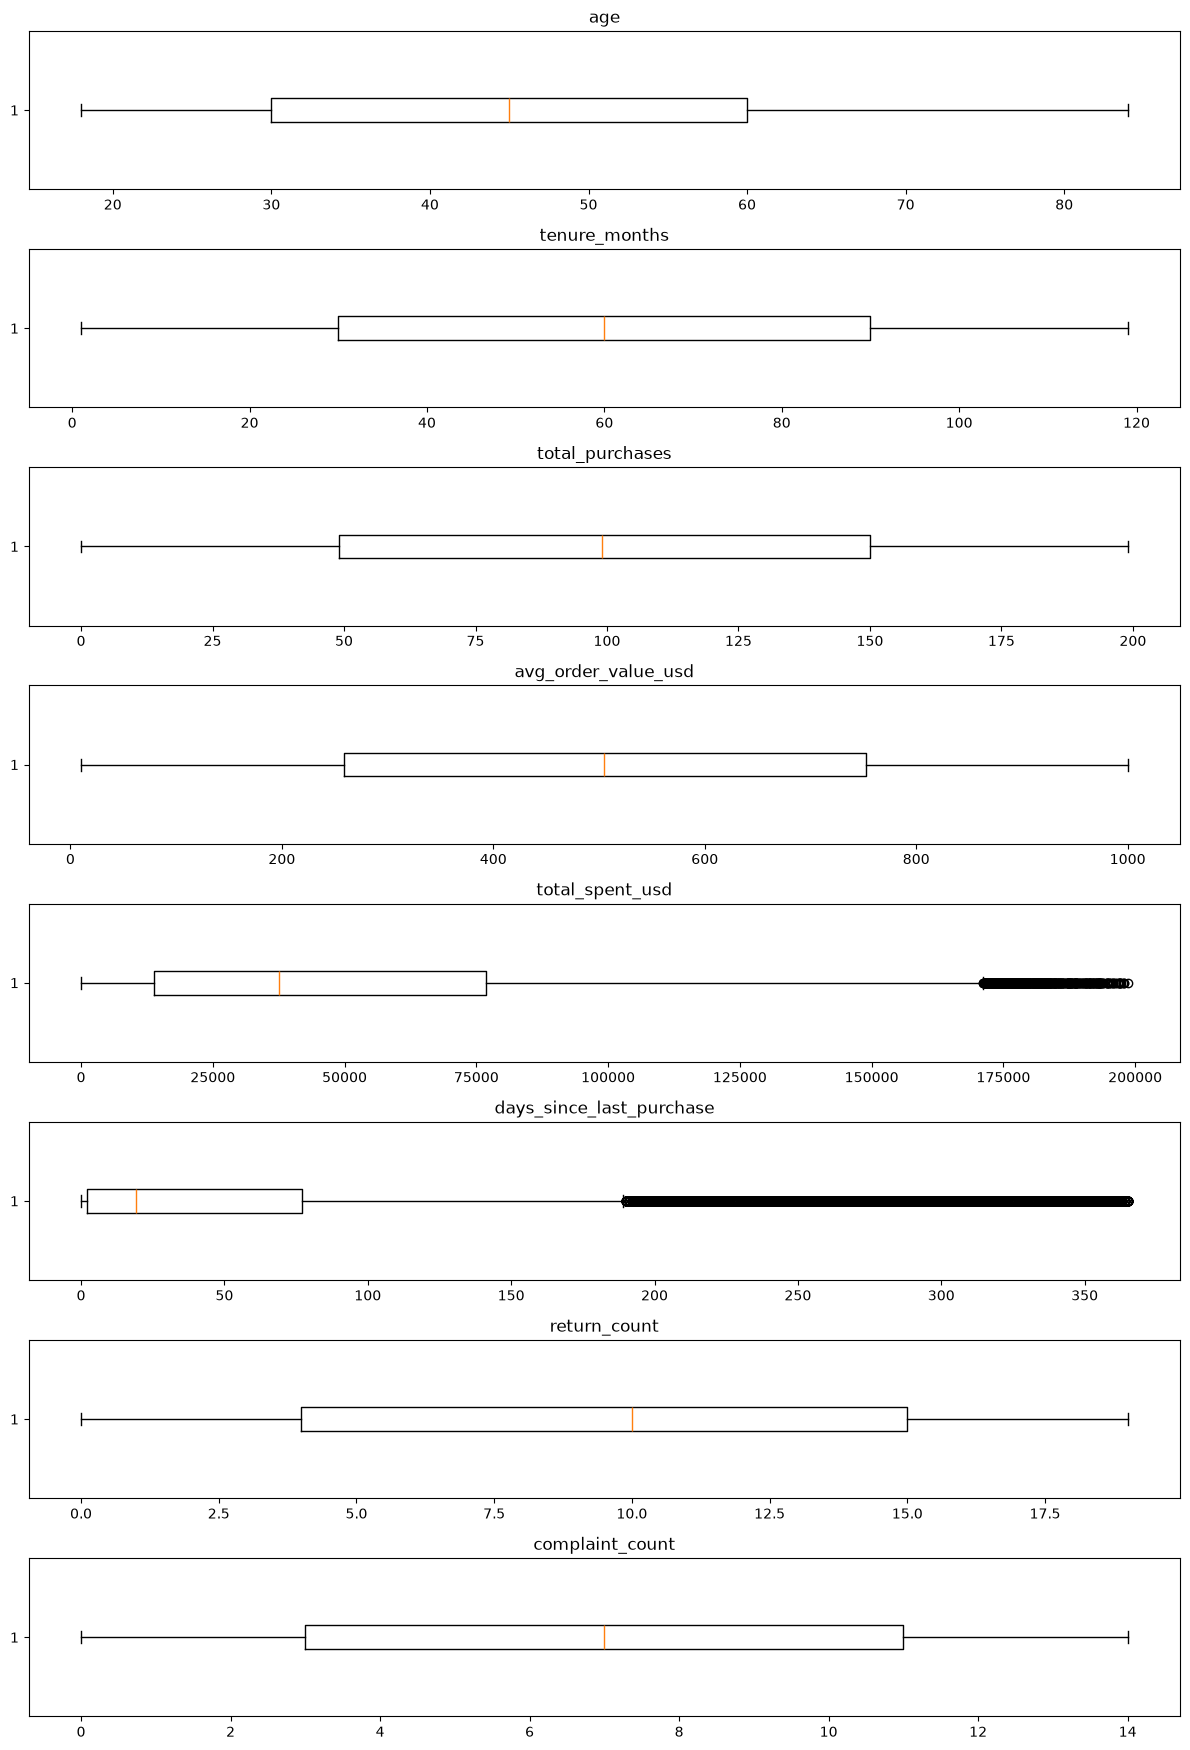

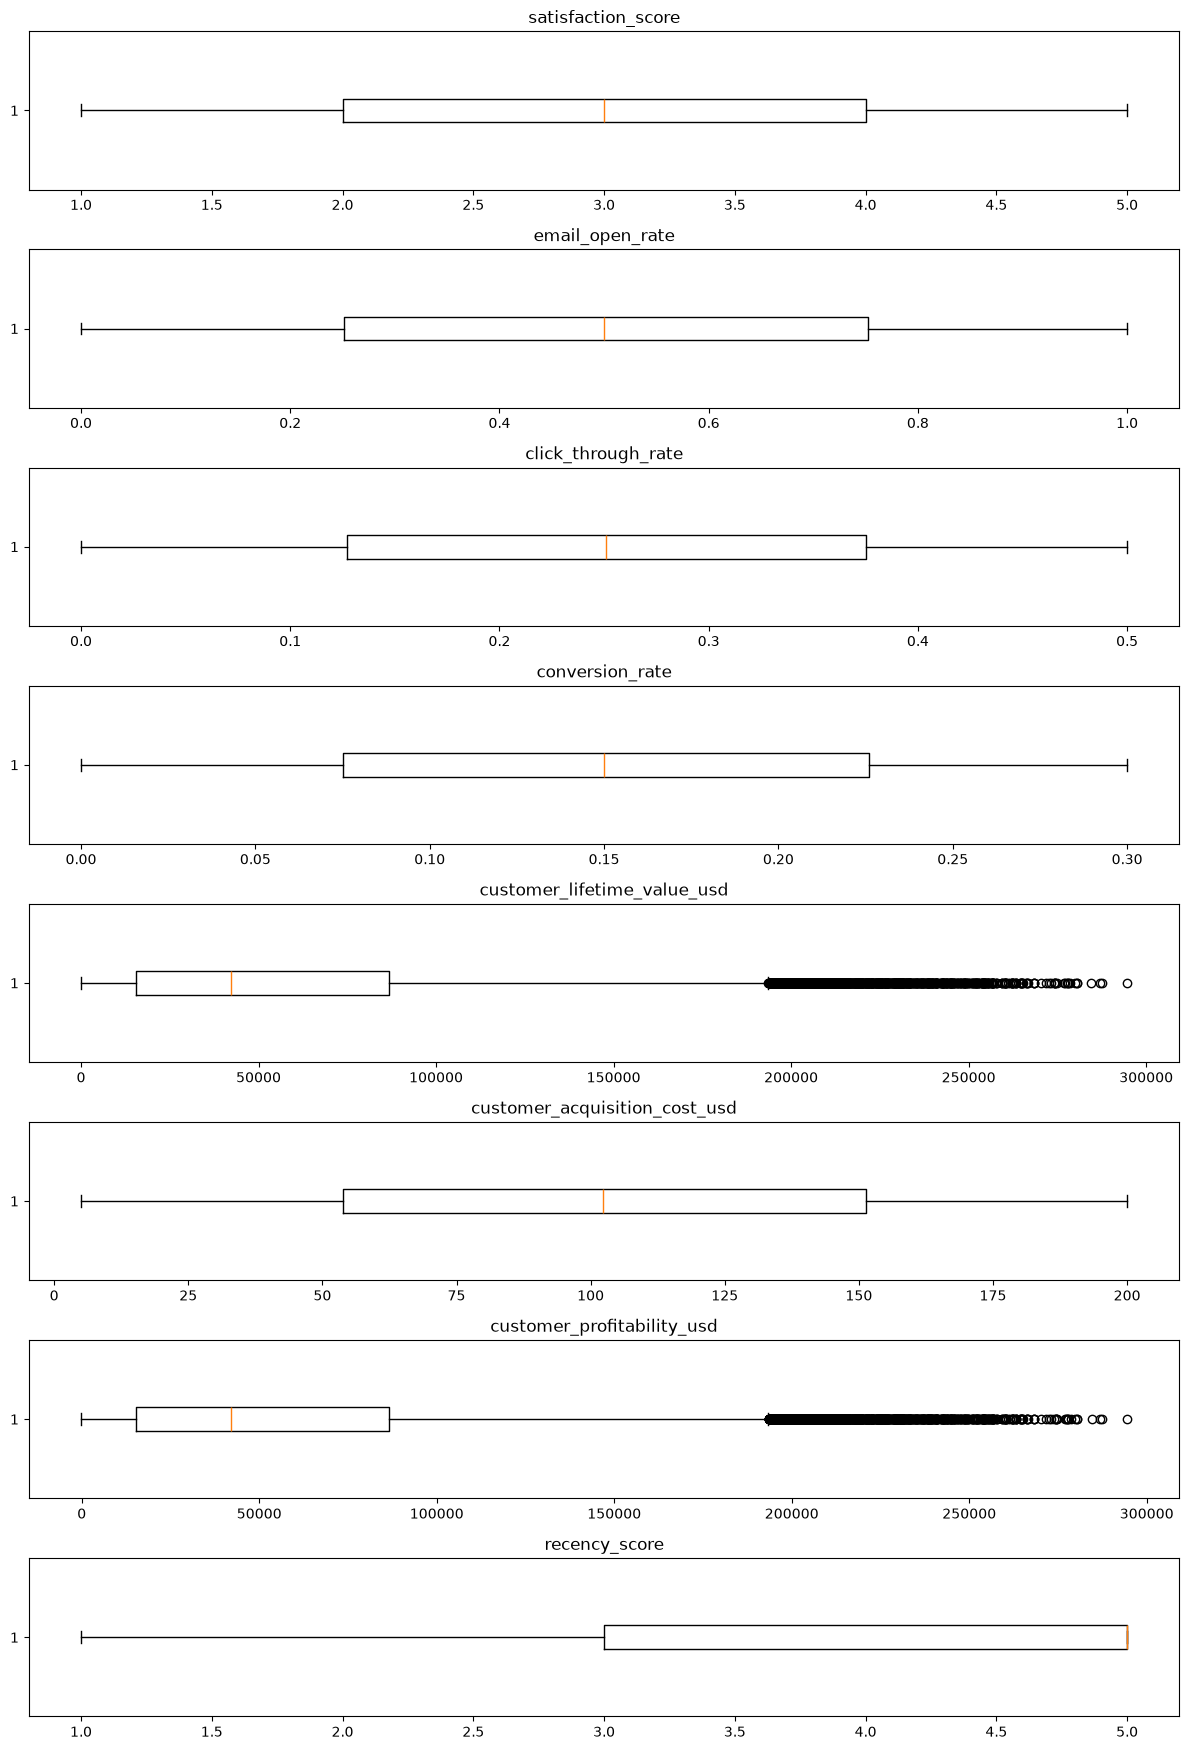

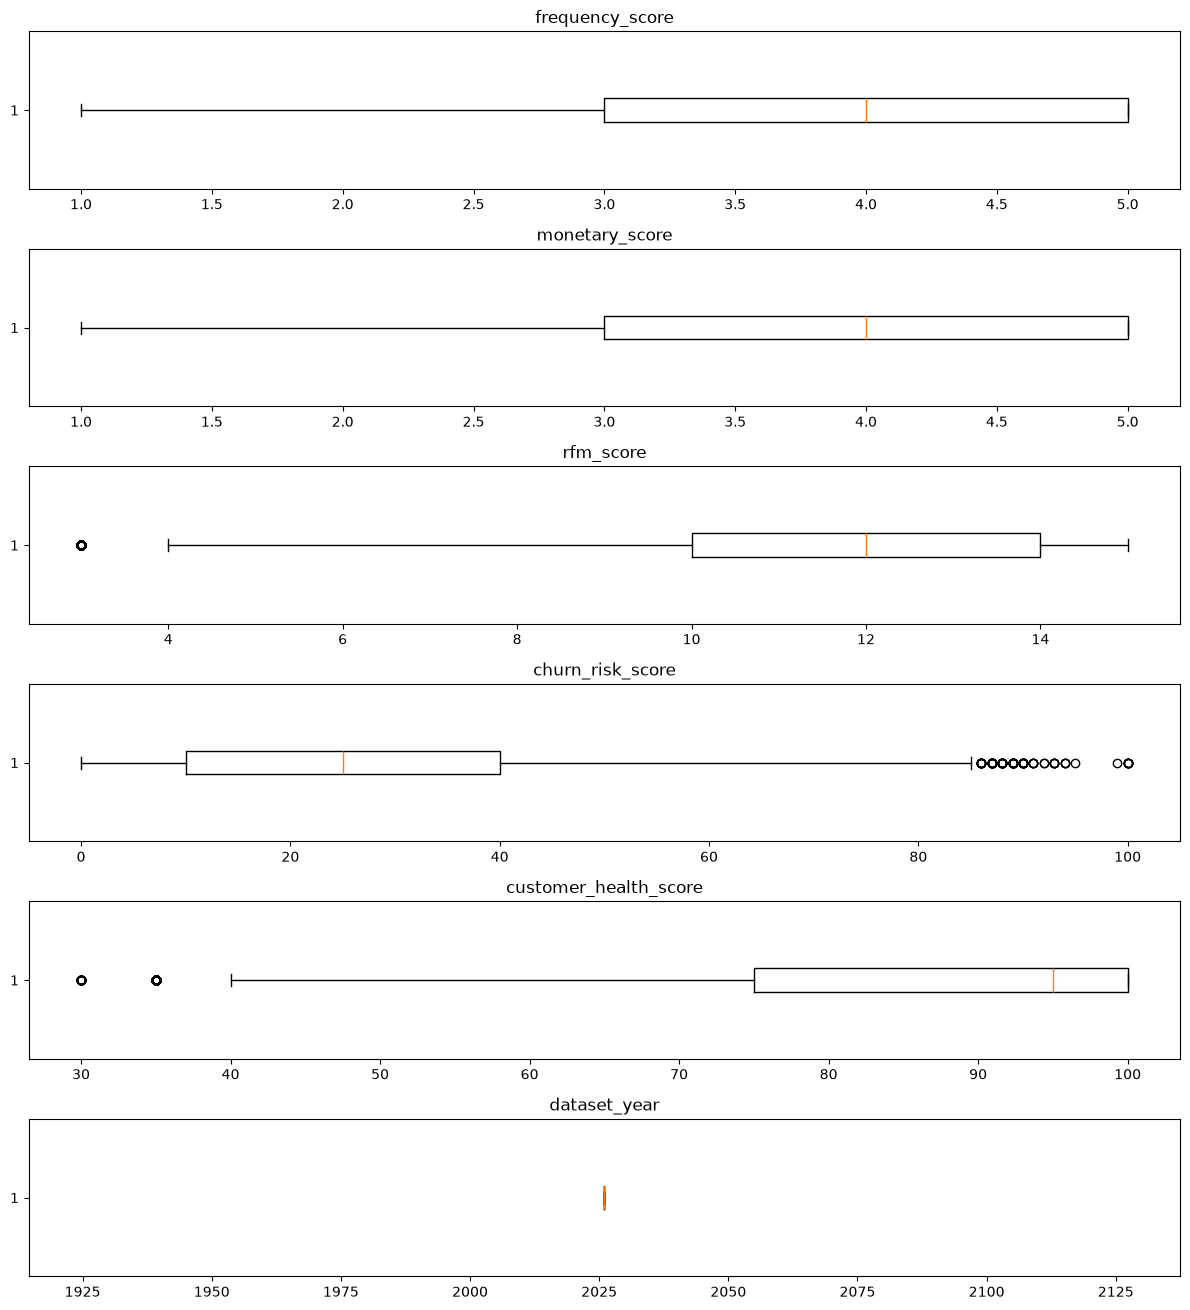

In [20]:
# Boxplots for numerical variables in small batches
for start in range(0, len(numeric_cols), 8):
    cols = numeric_cols[start:start+8]
    fig, axes = plt.subplots(len(cols), 1, figsize=(12, max(3, 2.2*len(cols))))
    if len(cols) == 1:
        axes = [axes]
    for ax, col in zip(axes, cols):
        ax.boxplot(df[col].dropna(), vert=False)
        ax.set_title(col)
    plt.tight_layout()
    plt.show()

## 11. Categorical distributions

In [21]:
categorical_cols = df.select_dtypes(exclude=np.number).columns.tolist()

categorical_summary = pd.DataFrame({
    "unique": df[categorical_cols].nunique(dropna=False),
    "missing": df[categorical_cols].isna().sum(),
    "missing_pct": df[categorical_cols].isna().mean() * 100
}).sort_values("unique")

display(categorical_summary)

,unique,missing,missing_pct
gender,2,0,0.0000
engagement_level,3,0,0.0000
clv_category,3,0,0.0000
device_preference,3,0,0.0000
device_used,4,0,0.0000
customer_segment,4,0,0.0000
shopping_channel,4,0,0.0000
marital_status,4,0,0.0000
health_status,4,0,0.0000
activity_status,4,0,0.0000


In [22]:
# Print manageable category distributions.
# High-cardinality columns are shown only with their most common values.
for col in categorical_cols:
    print("\n" + "="*80)
    print(col, "| unique:", df[col].nunique(dropna=False))
    display(df[col].value_counts(dropna=False).head(20).to_frame("count"))


customer_id | unique: 50000


,count
customer_id,
CUST-000001,1
CUST-000002,1
CUST-000003,1
CUST-000004,1
CUST-000005,1
CUST-000006,1
CUST-000007,1
CUST-000008,1
CUST-000009,1



customer_segment | unique: 4


,count
customer_segment,
Consumer,22507
Premium,12423
Small Business,9979
Enterprise,5091



segment_category | unique: 6


...

,count
behavior_segment,
Regular Buyer,17853
Occasional Buyer,15855
Frequent Buyer,14829
New Buyer,1463


device_preference | unique: 3


,count
device_preference,
Multi-Device,24867
Desktop-First,12745
Mobile-First,12388


clv_category | unique: 3


,count
clv_category,
High CLV,41093
Low CLV,5032
Medium CLV,3875


## 12. Verify suspected derived/redundant relationships

These tests are important because using a raw feature together with its exact derived version can double-count the same information during clustering.

### 12.1 Total spending relationship

In [23]:
calc_total_spent = df["total_purchases"] * df["avg_order_value_usd"]
spent_diff = (df["total_spent_usd"] - calc_total_spent).abs()

print("Maximum absolute difference:", spent_diff.max())
print("Approximately equal rows:",
      np.isclose(df["total_spent_usd"], calc_total_spent, rtol=1e-5, atol=1e-2).mean() * 100,
      "%")

Maximum absolute difference: 2.9103830456733704e-11
Approximately equal rows: 100.0 %


### 12.2 RFM score relationship

In [24]:
calc_rfm = df["recency_score"] + df["frequency_score"] + df["monetary_score"]

print("Exact matches:",
      (df["rfm_score"] == calc_rfm).mean() * 100,
      "%")

Exact matches: 100.0 %


### 12.3 Profitability relationship

In [25]:
calc_profit = df["customer_lifetime_value_usd"] - df["customer_acquisition_cost_usd"]

print("Approximately equal rows:",
      np.isclose(df["customer_profitability_usd"], calc_profit, rtol=1e-5, atol=1e-2).mean() * 100,
      "%")
print("Maximum absolute difference:",
      (df["customer_profitability_usd"] - calc_profit).abs().max())

Approximately equal rows: 100.0 %
Maximum absolute difference: 5.820766091346741e-11


### 12.4 Satisfaction score vs satisfaction level

In [26]:
display(pd.crosstab(
    df["satisfaction_score"],
    df["satisfaction_level"],
    normalize="index"
).round(3))

satisfaction_level,Dissatisfied,Neutral,Satisfied,Very Dissatisfied,Very Satisfied
satisfaction_score,,,,,
1,0.0000,0.0000,0.0000,1.0000,0.0000
2,1.0000,0.0000,0.0000,0.0000,0.0000
3,0.0000,1.0000,0.0000,0.0000,0.0000
4,0.0000,0.0000,1.0000,0.0000,0.0000
5,0.0000,0.0000,0.0000,0.0000,1.0000


### 12.5 Age vs age group

In [27]:
display(pd.crosstab(df["age_group"], pd.cut(
    df["age"],
    bins=[0, 24, 34, 44, 54, 64, np.inf],
    labels=["18-24", "25-34", "35-44", "45-54", "55-64", "65+"]
)))

age,18-24,25-34,35-44,45-54,55-64,65+
age_group,,,,,,
18-24,8349,0,0,0,0,0
25-34,0,8339,0,0,0,0
35-44,0,0,8203,0,0,0
45-54,0,0,0,8403,0,0
55-64,0,0,0,0,8266,0
65+,0,0,0,0,0,8440


### 12.6 Activity status vs recency

In [28]:
display(
    df.groupby("activity_status")["days_since_last_purchase"]
      .agg(["count", "min", "max", "mean", "median"])
      .sort_values("min")
)

,count,min,max,mean,median
activity_status,,,,,
Active,29412,0,29,7.4563,4.0000
At Risk,5237,30,59,43.7783,44.0000
Dormant,4994,60,89,74.4610,75.0000
Inactive,10357,90,365,224.7882,224.0000


### 12.7 Health status vs health score

In [29]:
display(
    df.groupby("health_status")["customer_health_score"]
      .agg(["count", "min", "max", "mean", "median"])
      .sort_values("min")
)

,count,min,max,mean,median
health_status,,,,,
Poor,316,30,40,35.1424,35.0000
Fair,4729,45,60,54.3064,55.0000
Good,12169,65,80,72.8864,70.0000
Excellent,32786,85,100,96.9569,100.0000


### 12.8 Device preference vs device used

In [30]:
display(pd.crosstab(df["device_used"], df["device_preference"], normalize="index").round(3))

device_preference,Desktop-First,Mobile-First,Multi-Device
device_used,,,
Desktop,1.0000,0.0000,0.0000
Mobile,0.0000,1.0000,0.0000
Multiple,0.0000,0.0000,1.0000
Tablet,0.0000,0.0000,1.0000


### 12.9 Engagement level vs engagement metrics

In [31]:
display(
    df.groupby("engagement_level")[
        ["email_open_rate", "click_through_rate", "conversion_rate"]
    ].agg(["count", "mean", "median", "min", "max"])
)

email_open_rate                              \
                           count   mean median    min    max   
engagement_level                                               
High                       15097 0.7514 0.7530 0.5010 1.0000   
Low                        15061 0.1498 0.1500 0.0000 0.3000   
Medium                     19842 0.5754 0.5000 0.3010 1.0000   

                 click_through_rate                              \
                              count   mean median    min    max   
engagement_level                                                  
High                          15097 0.3509 0.3510 0.2010 0.5000   
Low                           15061 0.2491 0.2490 0.0000 0.5000   
Medium                        19842 0.1758 0.1440 0.0000 0.5000   

                 conversion_rate                              
                           count   mean median    min    max  
engagement_level                                              
High                       15097 0.1504 0.1490 0.0000 0.3000  
Low                        15061 0.1498 0.1490 0.0000 0.3000  
Medium                     19842 0.1507 0.1520 0.0000 0.3000

## 13. Numerical correlation and redundancy

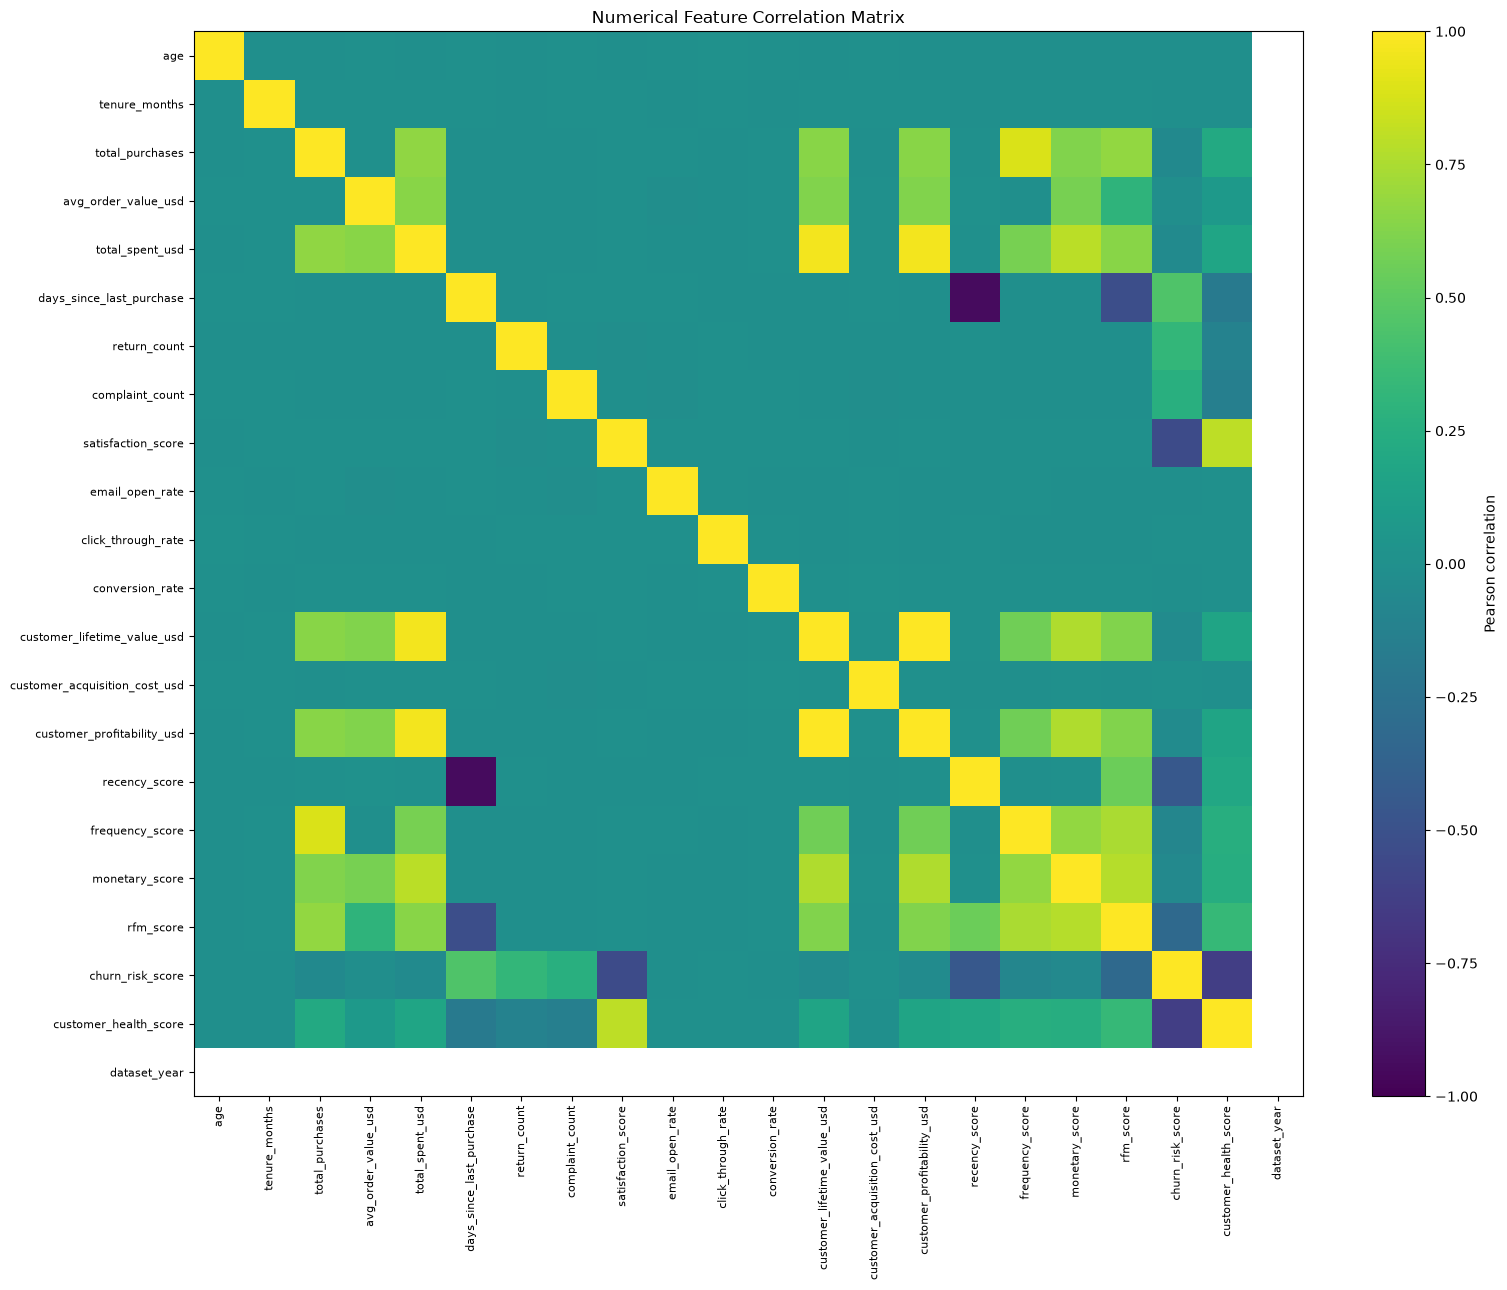

In [32]:
corr = df[numeric_cols].corr()

fig, ax = plt.subplots(figsize=(16, 13))
im = ax.imshow(corr, aspect="auto", vmin=-1, vmax=1)
ax.set_xticks(range(len(corr.columns)))
ax.set_xticklabels(corr.columns, rotation=90, fontsize=8)
ax.set_yticks(range(len(corr.index)))
ax.set_yticklabels(corr.index, fontsize=8)
fig.colorbar(im, ax=ax, label="Pearson correlation")
ax.set_title("Numerical Feature Correlation Matrix")
plt.tight_layout()
plt.show()

In [33]:
# Highly correlated numerical pairs
upper = corr.abs().where(np.triu(np.ones(corr.shape), k=1).astype(bool))

high_corr_pairs = (
    upper.stack()
         .reset_index()
         .rename(columns={"level_0": "feature_1",
                          "level_1": "feature_2",
                          0: "abs_correlation"})
         .query("abs_correlation >= 0.80")
         .sort_values("abs_correlation", ascending=False)
)

display(high_corr_pairs)

,feature_1,feature_2,abs_correlation
278,customer_lifetime_value_usd,customer_profitability_usd,1.0000
102,total_spent_usd,customer_profitability_usd,0.9665
100,total_spent_usd,customer_lifetime_value_usd,0.9664
125,days_since_last_purchase,recency_score,0.9389
60,total_purchases,frequency_score,0.8880
196,satisfaction_score,customer_health_score,0.8005


## 14. Special investigation: RFM raw variables vs scores

In [34]:
rfm_related = [
    "days_since_last_purchase",
    "total_purchases",
    "total_spent_usd",
    "recency_score",
    "frequency_score",
    "monetary_score",
    "rfm_score"
]

display(df[rfm_related].corr().round(3))

,days_since_last_purchase,total_purchases,total_spent_usd,recency_score,frequency_score,monetary_score,rfm_score
days_since_last_purchase,1.0000,-0.0040,-0.0050,-0.9390,-0.0020,-0.0040,-0.5210
total_purchases,-0.0040,1.0000,0.6670,0.0010,0.8880,0.6250,0.6740
total_spent_usd,-0.0050,0.6670,1.0000,0.0050,0.5900,0.7910,0.6410
recency_score,-0.9390,0.0010,0.0050,1.0000,-0.0000,0.0040,0.5540
frequency_score,-0.0020,0.8880,0.5900,-0.0000,1.0000,0.6750,0.7440
monetary_score,-0.0040,0.6250,0.7910,0.0040,0.6750,1.0000,0.7800
rfm_score,-0.5210,0.6740,0.6410,0.5540,0.7440,0.7800,1.0000


In [35]:
for score, raw in [
    ("recency_score", "days_since_last_purchase"),
    ("frequency_score", "total_purchases"),
    ("monetary_score", "total_spent_usd"),
]:
    print(f"\n{score} vs {raw}")
    display(
        df.groupby(score)[raw]
          .agg(["count", "min", "max", "mean", "median"])
    )


recency_score vs days_since_last_purchase


,count,min,max,mean,median
recency_score,,,,,
1,6781,181,365,273.0689,273.0000
2,3403,91,180,135.4337,135.0000
3,4988,61,90,75.5188,76.0000
4,4989,31,60,45.5396,45.0000
5,29839,0,30,7.7789,4.0000



frequency_score vs total_purchases


,count,min,max,mean,median
frequency_score,,,,,
1,1230,0,4,1.9870,2.0000
2,3811,5,19,12.1160,12.0000
3,7524,20,49,34.3381,34.0000
4,12463,50,99,74.7283,75.0000
5,24972,100,199,149.4716,150.0000



monetary_score vs total_spent_usd


,count,min,max,mean,median
monetary_score,,,,,
1,5531,0.0000,"4,997.3000","2,365.7205","2,303.6200"
2,4188,"5,000.4700","9,999.0000","7,396.5174","7,372.5000"
3,9446,"10,000.6500","24,999.3000","17,076.3535","16,838.0850"
4,10535,"25,000.1000","49,993.7200","36,674.7880","36,131.2000"
5,20300,"50,001.9200","198,574.1400","94,659.7914","87,381.0300"


## 15. Final feature-role master table

This table records the **final evidence-based role of every original dataset column** after the EDA above.  
The primary clustering model is intentionally behavioural. Demographics and existing business/segment labels are retained for later profiling/interpretation, while CLV and churn risk are kept strictly outside clustering for post-clustering prioritization.

In [36]:
feature_roles = {
    # Technical identifiers / metadata
    "index": ("technical_index", "exclude", "Technical row index; no behavioural meaning"),
    "customer_id": ("identifier", "keep_aside", "Retain only to identify customers after clustering"),
    "dataset_year": ("metadata", "exclude", "Constant value; provides no clustering information"),

    # Existing segments / derived labels — interpretation only or exclude
    "customer_segment": ("existing_segment", "interpretation_only", "Existing segmentation; must not define new clusters"),
    "segment_category": ("existing_segment", "interpretation_only", "Existing hard segment; use only to interpret new clusters"),
    "age_group": ("derived_category", "exclude", "Derived from age"),
    "satisfaction_level": ("derived_category", "exclude", "Derived from satisfaction_score"),
    "customer_value_category": ("derived_category", "interpretation_only", "Existing value grouping; not a clustering input"),
    "activity_status": ("derived_category", "interpretation_only", "Derived from recency/activity"),
    "health_status": ("derived_category", "interpretation_only", "Derived from customer_health_score"),
    "churn_risk_category": ("derived_business", "exclude", "Derived from churn information reserved for post-clustering use"),
    "rfm_category": ("derived_category", "interpretation_only", "Existing RFM segmentation"),
    "profitability_category": ("derived_business", "exclude", "Derived profitability grouping"),
    "engagement_level": ("derived_category", "exclude", "Existing engagement summary; detailed engagement rates are retained"),
    "behavior_segment": ("existing_segment", "interpretation_only", "Existing behavioural segmentation; use only for interpretation"),
    "device_preference": ("derived_category", "exclude", "Deterministic/overlapping representation of device_used"),
    "clv_category": ("derived_business", "exclude", "Derived from CLV, which is reserved for post-clustering prioritization"),
    "loyalty_tier": ("derived_business", "interpretation_only", "Existing loyalty/value label; not used to create new clusters"),

    # Post-clustering business prioritization
    "customer_lifetime_value_usd": ("post_clustering", "keep_aside", "Used after clustering to assess customer value"),
    "churn_risk_score": ("post_clustering", "keep_aside", "Used after clustering for retention prioritization"),

    # Final primary numerical clustering inputs
    "tenure_months": ("behavior_numeric", "include_primary", "Customer relationship duration"),
    "total_purchases": ("behavior_numeric", "include_primary", "Detailed purchase activity"),
    "avg_order_value_usd": ("behavior_numeric", "include_primary", "Average order-value behaviour"),
    "days_since_last_purchase": ("behavior_numeric", "include_primary", "Detailed recency; meaningful inactive customers are retained"),
    "return_count": ("behavior_numeric", "include_primary", "Return behaviour"),
    "complaint_count": ("behavior_numeric", "include_primary", "Complaint behaviour"),
    "satisfaction_score": ("behavior_ordinal", "include_primary", "Direct satisfaction measurement"),
    "email_open_rate": ("engagement_numeric", "include_primary", "Email engagement"),
    "click_through_rate": ("engagement_numeric", "include_primary", "Click engagement"),
    "conversion_rate": ("engagement_numeric", "include_primary", "Conversion behaviour"),

    # Final primary nominal clustering inputs
    "shopping_channel": ("behavior_nominal", "include_primary", "Low-cardinality shopping-channel behaviour"),
    "device_used": ("behavior_nominal", "include_primary", "Low-cardinality device behaviour"),

    # Redundant / derived numerical variables
    "total_spent_usd": ("derived_numeric", "exclude", "Redundant: total_purchases × avg_order_value_usd"),
    "recency_score": ("derived_rfm", "exclude", "Discretized version of detailed recency"),
    "frequency_score": ("derived_rfm", "exclude", "Discretized version of detailed purchase frequency"),
    "monetary_score": ("derived_rfm", "exclude", "Derived RFM component; avoid mixing raw and derived representations"),
    "rfm_score": ("derived_rfm", "exclude", "Exact sum of recency/frequency/monetary scores"),
    "customer_profitability_usd": ("derived_business", "exclude", "Derived from CLV minus acquisition cost; would reintroduce CLV information"),
    "customer_health_score": ("derived_score", "exclude", "Composite business score; underlying behaviours are preferred"),
    "customer_acquisition_cost_usd": ("business_numeric", "profiling_only", "Business metric not central to behavioural clustering"),

    # Demographics / geography — profile clusters after modelling
    "age": ("demographic_numeric", "profiling_only", "Retain for cluster profiling, not primary behavioural clustering"),
    "gender": ("demographic_nominal", "profiling_only", "Retain for cluster profiling"),
    "country": ("geographic_nominal", "profiling_only", "Retain for cluster profiling"),
    "city": ("geographic_nominal", "profiling_only", "High cardinality; profile clusters rather than expand clustering dimensions"),
    "income_bracket": ("demographic_ordinal", "profiling_only", "Retain for cluster profiling"),
    "education_level": ("demographic_nominal", "profiling_only", "Retain for cluster profiling"),
    "employment_type": ("demographic_nominal", "profiling_only", "Retain for cluster profiling"),
    "marital_status": ("demographic_nominal", "profiling_only", "Retain for cluster profiling"),

    # Other categorical behaviour / optional experiments
    "purchase_frequency": ("behavior_ordinal", "profiling_only", "Broad category overlaps with richer purchase/recency variables"),
    "payment_method": ("behavior_nominal", "profiling_only", "Retain for interpretation; not central to primary retention clustering"),
    "preferred_category_1": ("preference_multilabel", "optional_experiment", "Combine category 1/2/3 into multi-hot indicators if experimentally tested"),
    "preferred_category_2": ("preference_multilabel", "optional_experiment", "Meaningful missingness; combine with other preference columns if tested"),
    "preferred_category_3": ("preference_multilabel", "optional_experiment", "Meaningful missingness; combine with other preference columns if tested"),
    "social_media_presence": ("multilabel", "optional_experiment", "Parse into platform indicators if experimentally tested; missingness is retained as absence/not recorded"),
}

role_df = pd.DataFrame([
    {
        "feature": col,
        "dtype": str(df[col].dtype),
        "unique": df[col].nunique(dropna=False),
        "missing_pct": df[col].isna().mean() * 100,
        "role": feature_roles.get(col, ("UNASSIGNED", "", ""))[0],
        "final_decision": feature_roles.get(col, ("", "UNASSIGNED", ""))[1],
        "reason": feature_roles.get(col, ("", "", "Review manually"))[2],
    }
    for col in df.columns
])

display(role_df)
print("\nUnassigned features:")
display(role_df[role_df["role"] == "UNASSIGNED"])
print("Assigned features:", (role_df["role"] != "UNASSIGNED").sum(), "/", len(role_df))

,feature,dtype,unique,missing_pct,role,final_decision,reason
0,customer_id,str,50000,0.0000,identifier,keep_aside,Retain only to identify customers after cluste...
1,customer_segment,str,4,0.0000,existing_segment,interpretation_only,Existing segmentation; must not define new clu...
2,segment_category,str,6,0.0000,existing_segment,interpretation_only,Existing hard segment; use only to interpret n...
3,age,int64,67,0.0000,demographic_numeric,profiling_only,"Retain for cluster profiling, not primary beha..."
4,age_group,str,6,0.0000,derived_category,exclude,Derived from age
5,gender,str,2,0.0000,demographic_nominal,profiling_only,Retain for cluster profiling
6,country,str,17,0.0000,geographic_nominal,profiling_only,Retain for cluster profiling
7,city,str,157,0.0000,geographic_nominal,profiling_only,High cardinality; profile clusters rather than...
8,income_bracket,str,6,0.0000,demographic_ordinal,profiling_only,Retain for cluster profiling
9,education_level,str,5,0.0000,demographic_nominal,profiling_only,Retain for cluster profiling



Unassigned features:


,feature,dtype,unique,missing_pct,role,final_decision,reason


Assigned features: 53 / 53


## 16. Final modelling and preprocessing design

This is the **final corrected workflow**.

The earlier exploratory version fitted preprocessing to all 50,000 customers. For final modelling we instead:

1. select the 12 evidence-based raw clustering features;
2. split customers into **80% development / 20% holdout** using `random_state=42`;
3. fit `StandardScaler` and `OneHotEncoder` **only on the development set**;
4. use that fitted preprocessor to transform both development and holdout sets.

This avoids information from the holdout set influencing preprocessing.

Because this is an **unsupervised clustering** project, we use the terms *development* and *holdout*, not supervised `X_train/y_train` and `X_test/y_test`.

In [37]:
from sklearn.model_selection import train_test_split
import joblib
import json

numeric_candidates = [
    "tenure_months",
    "total_purchases",
    "avg_order_value_usd",
    "days_since_last_purchase",
    "return_count",
    "complaint_count",
    "satisfaction_score",
    "email_open_rate",
    "click_through_rate",
    "conversion_rate",
]

nominal_candidates = [
    "shopping_channel",
    "device_used",
]

candidate_cols = numeric_candidates + nominal_candidates

post_clustering_cols = [
    "customer_id",
    "customer_lifetime_value_usd",
    "churn_risk_score",
]

optional_experiment_groups = {
    "product_preferences": [
        "preferred_category_1",
        "preferred_category_2",
        "preferred_category_3",
    ],
    "social_media": ["social_media_presence"],
}

print("Primary raw clustering features:", len(candidate_cols))
print("Numerical:", numeric_candidates)
print("Nominal:", nominal_candidates)
print("Kept outside clustering:", post_clustering_cols)

Primary raw clustering features: 12
Numerical: ['tenure_months', 'total_purchases', 'avg_order_value_usd', 'days_since_last_purchase', 'return_count', 'complaint_count', 'satisfaction_score', 'email_open_rate', 'click_through_rate', 'conversion_rate']
Nominal: ['shopping_channel', 'device_used']
Kept outside clustering: ['customer_id', 'customer_lifetime_value_usd', 'churn_risk_score']


## 17. Validate selected raw features

The selected 12 primary clustering features should contain no missing values. Therefore the final primary pipeline does not add unnecessary imputers.

In [38]:
candidate_missing = pd.DataFrame({
    "missing_count": df[candidate_cols].isna().sum(),
    "missing_pct": df[candidate_cols].isna().mean() * 100,
})
display(candidate_missing)

assert candidate_missing["missing_count"].sum() == 0, (
    "Unexpected missing values found in the final primary feature set."
)
print("Validation passed: no missing values in the 12 primary clustering features.")

,missing_count,missing_pct
tenure_months,0,0.0000
total_purchases,0,0.0000
avg_order_value_usd,0,0.0000
days_since_last_purchase,0,0.0000
return_count,0,0.0000
complaint_count,0,0.0000
satisfaction_score,0,0.0000
email_open_rate,0,0.0000
click_through_rate,0,0.0000
conversion_rate,0,0.0000


Validation passed: no missing values in the 12 primary clustering features.


## 18. Create the common 80/20 development–holdout split

The split is performed **before fitting preprocessing**.

- Development: 80% = 40,000 customers
- Holdout: 20% = 10,000 customers
- Random state: 42

The same split must be used by all four group members so model results remain comparable.

In [39]:
all_indices = df.index.to_numpy()

development_idx, holdout_idx = train_test_split(
    all_indices,
    test_size=0.20,
    random_state=42,
    shuffle=True,
)

# Sorting does not change membership; it simply preserves original row order in exports.
development_idx = np.sort(development_idx)
holdout_idx = np.sort(holdout_idx)

X_development_raw = df.loc[development_idx, candidate_cols].copy()
X_holdout_raw = df.loc[holdout_idx, candidate_cols].copy()

print("Full dataset:", len(df))
print("Development:", len(X_development_raw))
print("Holdout:", len(X_holdout_raw))
print("Overlap:", len(set(development_idx).intersection(set(holdout_idx))))

assert len(X_development_raw) == 40000
assert len(X_holdout_raw) == 10000
assert len(set(development_idx).intersection(set(holdout_idx))) == 0

Full dataset: 50000
Development: 40000
Holdout: 10000
Overlap: 0


## 19. Fit preprocessing on the development set only

- 10 numerical behavioural variables → `StandardScaler`
- `shopping_channel` and `device_used` → `OneHotEncoder`
- `handle_unknown="ignore"` allows future/holdout records to be transformed safely if an unseen category appears.

**Important:** the holdout data is never used in `fit()`.

In [40]:
numeric_pipeline = Pipeline(steps=[
    ("scaler", StandardScaler()),
])

nominal_pipeline = Pipeline(steps=[
    ("onehot", OneHotEncoder(handle_unknown="ignore", sparse_output=False)),
])

preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_pipeline, numeric_candidates),
        ("cat", nominal_pipeline, nominal_candidates),
    ],
    remainder="drop",
    verbose_feature_names_out=False,
)

# FIT only on development data.
X_development_processed = preprocessor.fit_transform(X_development_raw)

# TRANSFORM holdout using the already-fitted development preprocessor.
X_holdout_processed = preprocessor.transform(X_holdout_raw)

feature_names = preprocessor.get_feature_names_out()

development_preprocessed = pd.DataFrame(
    X_development_processed,
    columns=feature_names,
    index=development_idx,
)

holdout_preprocessed = pd.DataFrame(
    X_holdout_processed,
    columns=feature_names,
    index=holdout_idx,
)

print("Development processed shape:", development_preprocessed.shape)
print("Holdout processed shape:", holdout_preprocessed.shape)
print("Processed feature count:", len(feature_names))
print("\nProcessed features:")
print(feature_names.tolist())
display(development_preprocessed.head())

Development processed shape: (40000, 18)
Holdout processed shape: (10000, 18)
Processed feature count: 18

Processed features:
['tenure_months', 'total_purchases', 'avg_order_value_usd', 'days_since_last_purchase', 'return_count', 'complaint_count', 'satisfaction_score', 'email_open_rate', 'click_through_rate', 'conversion_rate', 'shopping_channel_In-Store', 'shopping_channel_Marketplace', 'shopping_channel_Mobile App', 'shopping_channel_Online', 'device_used_Desktop', 'device_used_Mobile', 'device_used_Multiple', 'device_used_Tablet']


,tenure_months,total_purchases,avg_order_value_usd,days_since_last_purchase,return_count,complaint_count,satisfaction_score,email_open_rate,click_through_rate,conversion_rate,shopping_channel_In-Store,shopping_channel_Marketplace,shopping_channel_Mobile App,shopping_channel_Online,device_used_Desktop,device_used_Mobile,device_used_Multiple,device_used_Tablet
0,0.5056,-1.2366,1.4279,0.0030,0.9474,1.3881,1.4039,-1.6649,-1.2784,-1.4793,1.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,1.0000
1,0.5931,-0.4237,-0.7152,3.0030,-1.4710,1.6193,1.4039,-1.4369,-1.1535,1.6403,0.0000,1.0000,0.0000,0.0000,1.0000,0.0000,0.0000,0.0000
2,0.7681,1.0983,0.5567,0.0138,-1.4710,-0.6926,-0.0079,-0.7636,1.2260,0.8230,1.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,1.0000
3,-0.9822,1.5999,0.3804,-0.6529,0.2564,0.2322,1.4039,1.3774,0.2131,-0.0980,0.0000,0.0000,0.0000,1.0000,0.0000,1.0000,0.0000,0.0000
5,1.0015,0.1989,-0.2856,-0.6529,1.1201,-0.4614,1.4039,-1.1780,-0.7165,1.3065,1.0000,0.0000,0.0000,0.0000,0.0000,0.0000,1.0000,0.0000


## 20. Verify the final processed data

We verify:

- no missing values;
- no infinite values;
- the development numerical variables have mean approximately 0 and standard deviation approximately 1 after scaling.

The holdout set is **not expected** to have exactly zero mean/unit standard deviation because its scaling parameters came from the development set.

In [41]:
assert development_preprocessed.isna().sum().sum() == 0
assert holdout_preprocessed.isna().sum().sum() == 0

assert np.isfinite(development_preprocessed.to_numpy()).all()
assert np.isfinite(holdout_preprocessed.to_numpy()).all()

scaled_check = pd.DataFrame({
    "mean": development_preprocessed[numeric_candidates].mean(),
    "std": development_preprocessed[numeric_candidates].std(ddof=0),
})

display(scaled_check)
print("Development NaNs:", development_preprocessed.isna().sum().sum())
print("Holdout NaNs:", holdout_preprocessed.isna().sum().sum())
print("All validation checks passed.")

,mean,std
tenure_months,0.0000,1.0000
total_purchases,-0.0000,1.0000
avg_order_value_usd,-0.0000,1.0000
days_since_last_purchase,0.0000,1.0000
return_count,0.0000,1.0000
complaint_count,-0.0000,1.0000
satisfaction_score,0.0000,1.0000
email_open_rate,-0.0000,1.0000
click_through_rate,0.0000,1.0000
conversion_rate,-0.0000,1.0000


Development NaNs: 0
Holdout NaNs: 0
All validation checks passed.


## 21. Optional feature-engineering experiments — not primary model inputs

The following transformations are retained only for later controlled experiments. They are **not** silently added to the 18-feature primary clustering matrix.

### 21.1 Product preferences → multi-hot indicators

In [42]:
preference_cols = [
    "preferred_category_1",
    "preferred_category_2",
    "preferred_category_3",
]

all_preference_categories = sorted(
    set(
        df[preference_cols]
        .stack()
        .dropna()
        .astype(str)
        .unique()
    )
)

preference_features = pd.DataFrame(index=df.index)

for category in all_preference_categories:
    preference_features[f"pref_{category}"] = (
        df[preference_cols].eq(category).any(axis=1).astype(int)
    )

print("Optional product-preference indicators:", preference_features.shape[1])
display(preference_features.head())

Optional product-preference indicators: 12


,pref_Automotive,pref_Beauty,pref_Books,pref_Electronics,pref_Fashion,pref_Grocery,pref_Health & Personal Care,pref_Home & Kitchen,pref_Office Supplies,pref_Pet Supplies,pref_Sports & Fitness,pref_Toys
0,0,0,0,0,0,0,0,1,0,0,1,0
1,1,1,0,0,1,0,0,0,0,0,0,0
2,1,1,0,0,1,0,0,0,0,0,0,0
3,0,0,0,1,0,0,0,0,0,0,0,1
4,0,0,0,0,0,1,0,1,1,0,0,0


### 21.2 Social-media combinations → multi-hot platform indicators

In [43]:
social_media_features = (
    df["social_media_presence"]
    .fillna("")
    .str.get_dummies(sep=", ")
)

social_media_features = social_media_features.loc[
    :, social_media_features.columns != ""
]

social_media_features.columns = [
    f"social_{col}" for col in social_media_features.columns
]

print("Optional social-media indicators:", social_media_features.shape[1])
display(social_media_features.head())

Optional social-media indicators: 6


,social_Facebook,social_Instagram,social_LinkedIn,social_TikTok,social_Twitter,social_YouTube
0,0,0,0,0,0,0
1,0,0,0,0,0,0
2,0,0,0,0,0,0
3,0,0,0,1,1,1
4,0,0,0,1,0,1


## 22. Preserve business and profiling data separately

These variables do **not** enter cluster formation.

- `customer_id` → alignment/identification only
- CLV + churn risk → post-clustering business prioritization
- demographics/existing labels → post-clustering profiling and interpretation

Separate development and holdout versions are created using exactly the same row split.

In [44]:
business_cols = [
    "customer_id",
    "customer_lifetime_value_usd",
    "churn_risk_score",
]

profiling_cols = [
    "customer_id",
    "age",
    "gender",
    "country",
    "city",
    "income_bracket",
    "education_level",
    "employment_type",
    "marital_status",
    "purchase_frequency",
    "payment_method",
    "loyalty_tier",
    "customer_segment",
    "segment_category",
    "customer_value_category",
    "activity_status",
    "health_status",
    "rfm_category",
    "engagement_level",
    "behavior_segment",
    "device_preference",
]

development_business = df.loc[development_idx, business_cols].copy()
holdout_business = df.loc[holdout_idx, business_cols].copy()

development_profiling = df.loc[development_idx, profiling_cols].copy()
holdout_profiling = df.loc[holdout_idx, profiling_cols].copy()

print("Development business:", development_business.shape)
print("Holdout business:", holdout_business.shape)
print("Development profiling:", development_profiling.shape)
print("Holdout profiling:", holdout_profiling.shape)

Development business: (40000, 3)
Holdout business: (10000, 3)
Development profiling: (40000, 21)
Holdout profiling: (10000, 21)


## 23. Build export files for the four-member modelling stage

`customer_id` is included in CSV exports **only to keep rows aligned across files**.

Before fitting a clustering model, every member must use:

```python
X = development_preprocessed.drop(columns="customer_id")
```

The ID must never be passed to a clustering algorithm.

In [45]:
development_raw_export = df.loc[
    development_idx, ["customer_id"] + candidate_cols
].copy()

holdout_raw_export = df.loc[
    holdout_idx, ["customer_id"] + candidate_cols
].copy()

development_preprocessed_export = development_preprocessed.copy()
development_preprocessed_export.insert(
    0, "customer_id", df.loc[development_idx, "customer_id"].to_numpy()
)

holdout_preprocessed_export = holdout_preprocessed.copy()
holdout_preprocessed_export.insert(
    0, "customer_id", df.loc[holdout_idx, "customer_id"].to_numpy()
)

print("Development export:", development_preprocessed_export.shape)
print("Holdout export:", holdout_preprocessed_export.shape)
display(development_preprocessed_export.head())

Development export: (40000, 19)
Holdout export: (10000, 19)


,customer_id,tenure_months,total_purchases,avg_order_value_usd,days_since_last_purchase,return_count,complaint_count,satisfaction_score,email_open_rate,click_through_rate,conversion_rate,shopping_channel_In-Store,shopping_channel_Marketplace,shopping_channel_Mobile App,shopping_channel_Online,device_used_Desktop,device_used_Mobile,device_used_Multiple,device_used_Tablet
0,CUST-000001,0.5056,-1.2366,1.4279,0.0030,0.9474,1.3881,1.4039,-1.6649,-1.2784,-1.4793,1.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,1.0000
1,CUST-000002,0.5931,-0.4237,-0.7152,3.0030,-1.4710,1.6193,1.4039,-1.4369,-1.1535,1.6403,0.0000,1.0000,0.0000,0.0000,1.0000,0.0000,0.0000,0.0000
2,CUST-000003,0.7681,1.0983,0.5567,0.0138,-1.4710,-0.6926,-0.0079,-0.7636,1.2260,0.8230,1.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,1.0000
3,CUST-000004,-0.9822,1.5999,0.3804,-0.6529,0.2564,0.2322,1.4039,1.3774,0.2131,-0.0980,0.0000,0.0000,0.0000,1.0000,0.0000,1.0000,0.0000,0.0000
5,CUST-000006,1.0015,0.1989,-0.2856,-0.6529,1.1201,-0.4614,1.4039,-1.1780,-0.7165,1.3065,1.0000,0.0000,0.0000,0.0000,0.0000,0.0000,1.0000,0.0000


## 24. Save the final shared modelling artifacts

In [46]:
# Save final shared modelling artifacts to data/processed and models
development_raw_export.to_csv(
    PROCESSED_DATA_DIR / "development_raw.csv", index=False
)
holdout_raw_export.to_csv(
    PROCESSED_DATA_DIR / "holdout_raw.csv", index=False
)

development_preprocessed_export.to_csv(
    PROCESSED_DATA_DIR / "development_preprocessed.csv", index=False
)
holdout_preprocessed_export.to_csv(
    PROCESSED_DATA_DIR / "holdout_preprocessed.csv", index=False
)

development_business.to_csv(
    PROCESSED_DATA_DIR / "development_business_data.csv", index=False
)
holdout_business.to_csv(
    PROCESSED_DATA_DIR / "holdout_business_data.csv", index=False
)

development_profiling.to_csv(
    PROCESSED_DATA_DIR / "development_profiling_data.csv", index=False
)
holdout_profiling.to_csv(
    PROCESSED_DATA_DIR / "holdout_profiling_data.csv", index=False
)

feature_decision_df = role_df.copy()
feature_decision_df.to_csv(
    PROCESSED_DATA_DIR / "final_feature_decisions.csv", index=False
)

joblib.dump(
    preprocessor,
    MODELS_DIR / "modelling_preprocessor.pkl"
)

split_metadata = {
    "original_row_count": int(len(df)),
    "dataset_rows": int(len(df)),
    "development_row_count": int(len(development_idx)),
    "development_rows": int(len(development_idx)),
    "holdout_row_count": int(len(holdout_idx)),
    "holdout_rows": int(len(holdout_idx)),
    "split_ratio": {"development": 0.80, "holdout": 0.20},
    "development_ratio": 0.80,
    "holdout_ratio": 0.20,
    "random_state": 42,
    "shuffle": True,
    "split_type": "random development-holdout split for unsupervised clustering",
    "raw_selected_feature_count": int(len(candidate_cols)),
    "raw_model_feature_count": int(len(candidate_cols)),
    "processed_feature_count": int(len(feature_names)),
    "processed_model_feature_count": int(len(feature_names)),
    "numerical_feature_names": numeric_candidates,
    "numeric_features": numeric_candidates,
    "categorical_feature_names": nominal_candidates,
    "categorical_features": nominal_candidates,
    "final_processed_feature_names": feature_names.tolist(),
    "processed_feature_names": feature_names.tolist(),
    "preprocessing_fit_scope": "development set only",
    "fitted_on_development_only": True,
    "business_fields_excluded_from_clustering": [
        "customer_lifetime_value_usd",
        "churn_risk_score",
    ],
}

with open(PROCESSED_DATA_DIR / "split_metadata.json", "w", encoding="utf-8") as f:
    json.dump(split_metadata, f, indent=2)

print("Final modelling artifacts saved.")
print(f"Processed datasets and metadata saved to: {PROCESSED_DATA_DIR}")
print(f"Modelling preprocessor saved to: {MODELS_DIR / 'modelling_preprocessor.pkl'}")


Final modelling artifacts saved.
Processed datasets and metadata saved to: C:\Users\ASUS\Pictures\final fdm\data\processed
Modelling preprocessor saved to: C:\Users\ASUS\Pictures\final fdm\models\modelling_preprocessor.pkl


# Final EDA + Preprocessing + Validation Checklist

This single notebook now contains the complete workflow from the original dataset through the final common modelling datasets.

- [x] Load original 50,000 × 53 dataset
- [x] Dataset structure/type investigation
- [x] Duplicate analysis
- [x] Missing-value analysis
- [x] Constant/near-constant analysis
- [x] Invalid/range checks
- [x] Distribution/skewness analysis
- [x] Outlier investigation
- [x] Categorical analysis
- [x] Derived/redundant relationship checks
- [x] Correlation analysis
- [x] RFM raw-vs-derived investigation
- [x] Evidence-based feature-role table for all original columns
- [x] Final 12 raw primary clustering features
- [x] 80/20 development–holdout split **before preprocessing fit**
- [x] Preprocessor fitted only on development data
- [x] 10 numerical features standardized
- [x] 2 nominal features one-hot encoded
- [x] 18 final processed model features
- [x] Holdout transformed without refitting
- [x] CLV/churn kept outside clustering
- [x] Profiling variables kept outside clustering
- [x] Optional preference/social-media experiments kept separate
- [x] Reusable fitted preprocessor saved
- [x] Shared development/holdout files created for all four members

## Next phase

All four members now use the same `development_preprocessed.csv` and `holdout_preprocessed.csv`.

1. Member 1 — K-Means
2. Member 2 — Gaussian Mixture Model
3. Member 3 — Fuzzy C-Means
4. Member 4 — Agglomerative Clustering

Model tuning and comparison should be done in separate modelling notebooks. This notebook remains the group's final common EDA/preprocessing/validation notebook.